# Figure 1 in paper

In [1]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sb
import skimage

In [ ]:
df = pd.read_csv('/scr/yren/annotated_mn_datasets/metadata.csv')
df[(df.datasets == 'screen') & (df.split == 'validation')]

,filenames,datasets,magnification,micron,split,cell_line
9,C2-20X_c0-DAPI-GFP_B3_Tile-16.phenotype.tif,screen,14,4.25,validation,HeLa
15,C2-20X_c0-DAPI-GFP_A2_Tile-5.phenotype.tif,screen,14,4.25,validation,HeLa


In [ ]:
image = 'C2-20X_c0-DAPI-GFP_A2_Tile-5.phenotype.tif'
path = '/scr/yren/annotated_mn_datasets/validation/' + image

im = skimage.io.imread(path)
print(im.shape)

(2960, 2960)


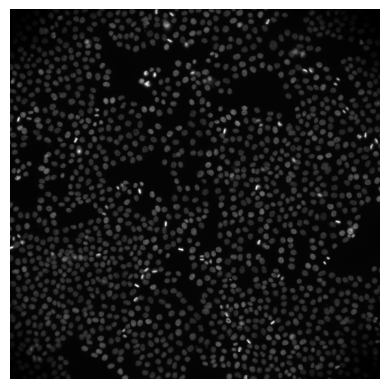

In [4]:
plt.imshow(im, cmap='gray')
plt.axis('off')
plt.show()

In [5]:
nuclei_mask = skimage.io.imread(path.replace('.phenotype.tif', '.nuclei-clean.tif'))
print(nuclei_mask.shape)

(2960, 2960)


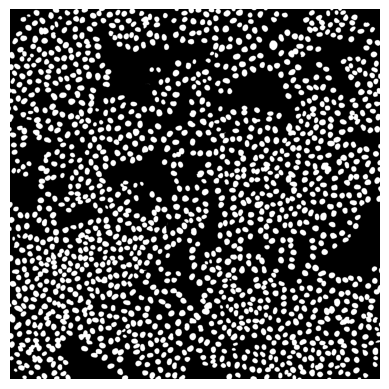

In [6]:
plt.imshow(nuclei_mask > 0, cmap='gray')
plt.axis('off')
plt.show()

In [7]:
micro_mask = skimage.io.imread(path.replace('.phenotype.tif', '.phenotype_outlines.png'))
print(micro_mask.shape)

(2960, 2960)


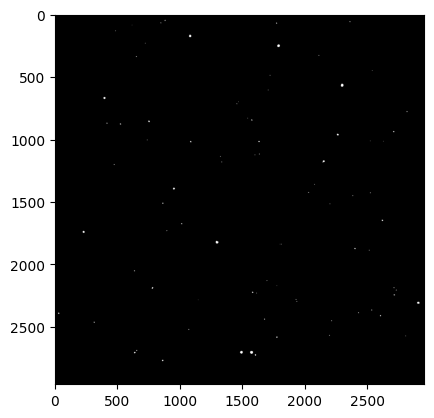

In [8]:
plt.imshow(micro_mask > 0, cmap='gray')
# plt.axis('off')
plt.show()

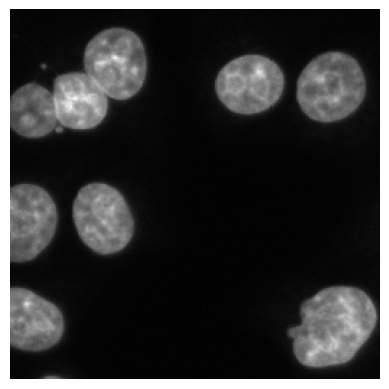

In [9]:
# R,C = 1000,1100
R,C = 1100,1300
P = 256
# plt.figure(figsize=(8,8))
plt.imshow(im[R:R+P,C:C+P], cmap='gray')
plt.xlabel(P)
plt.ylabel(P)
plt.xticks([])
plt.yticks([])
plt.axis('off')
plt.show()

In [10]:
import torch

In [11]:
patch = im[R:R+P,C:C+P]
px = np.concatenate(
        (patch[np.newaxis,:,:], patch[np.newaxis,:,:], patch[np.newaxis,:,:]), 
        axis=0)

In [12]:
px = torch.Tensor(px)
px = px.unsqueeze(0)
print(px.shape)

torch.Size([1, 3, 256, 256])


In [13]:
B,C,H,W = px.shape

In [14]:
px = torch.nn.functional.interpolate(px, (448,448))
print(px.shape)

torch.Size([1, 3, 448, 448])


In [15]:
device = 'cuda:1'

In [16]:
feature_extractor = torch.hub.load('facebookresearch/dinov2', 'dinov2_vits14_reg').to(device)

Using cache found in /home/MORGRIDGE/yren/.cache/torch/hub/facebookresearch_dinov2_main
/home/MORGRIDGE/yren/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/swiglu_ffn.py:51: UserWarning: xFormers is not available (SwiGLU)
  warnings.warn("xFormers is not available (SwiGLU)")
/home/MORGRIDGE/yren/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/attention.py:33: UserWarning: xFormers is not available (Attention)
  warnings.warn("xFormers is not available (Attention)")
/home/MORGRIDGE/yren/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/block.py:40: UserWarning: xFormers is not available (Block)
  warnings.warn("xFormers is not available (Block)")


In [17]:
px = px.to(device)

In [18]:
out = feature_extractor.forward_features(px)['x_norm_patchtokens']

In [19]:
print(out.shape)
B,T,C = out.shape

torch.Size([1, 1024, 384])


In [20]:
H,W = 32,32
out = out.reshape(B,H,W,C).permute(0,3,1,2)
print(out.shape)

torch.Size([1, 384, 32, 32])


In [21]:
features = out.squeeze(0)
print(features.shape)

torch.Size([384, 32, 32])


# PCA

In [22]:
from sklearn.decomposition import PCA

In [23]:
print(features.shape)

torch.Size([384, 32, 32])


In [24]:
features = features.reshape(384, 1024)
features = features.permute(1,0)
features = features.detach().cpu().numpy()
print(features.shape) # 1024 samples (tokens), 384 features (which will be reduced to 3 RGB channels)

(1024, 384)


In [39]:
pca = PCA(n_components=3) # RGB channels
decomposed = pca.fit_transform(features)

In [40]:
print(decomposed.shape)
decomposed = decomposed.reshape(32,32,3)

(1024, 3)


In [41]:
print(decomposed.shape)
print(np.unique(decomposed))

(32, 32, 3)
[-52.182663 -51.565273 -51.17718  ...  28.334238  28.671753  29.606434]


In [44]:
im2 = np.zeros_like(decomposed)
for i in range(3):
    im2[:,:,i] = (decomposed[:,:,i] - np.min(decomposed[:,:,i])) / (np.max(decomposed[:,:,i]) - np.min(decomposed[:,:,i]))
    # im2[:,:,i] = (im2[:,:,i] * 255).astype(np.uint8)
    

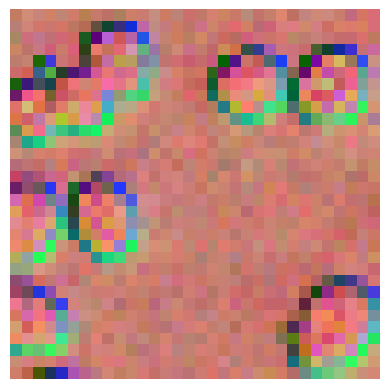

In [49]:
plt.imshow(im2[:,:,:])
plt.axis('off')
plt.show()

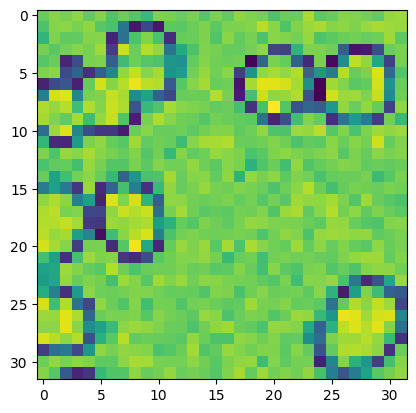

In [50]:
plt.imshow(im2[:,:,0])

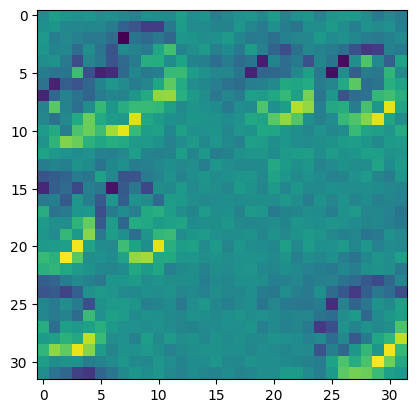

In [51]:
plt.imshow(im2[:,:,1])

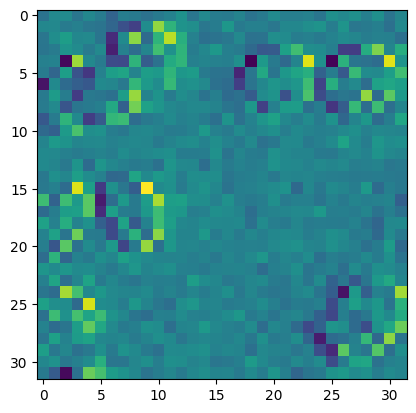

In [52]:
plt.imshow(im2[:,:,2])

In [34]:
print(np.min(decomposed[:,:,2]), np.max(decomposed[:,:,2]))

85 255


In [ ]:
path = '/scr/yren/micronuclei-detection/src/dinomn/annotated_mn_datasets/validation/model_output/output/'
validation_file = image.replace('.phenotype.tif', 'phenotype_outlines.png')
nuc_pred = np.load(path + validation_file.replace('phenotype_outlines.png','_nuc_probabilities.npy'))
mic_pred = np.load(path + validation_file.replace('phenotype_outlines.png','_mn_probabilities.npy'))

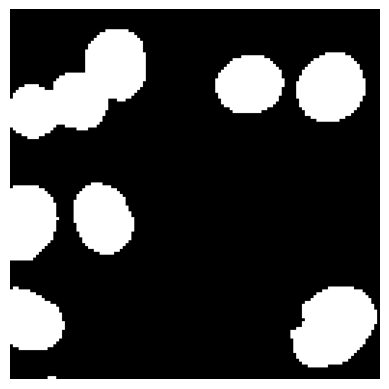

In [167]:
plt.imshow(nuc_pred[R:R+P,C:C+P] > 0, cmap='gray')
plt.axis('off')
plt.show()

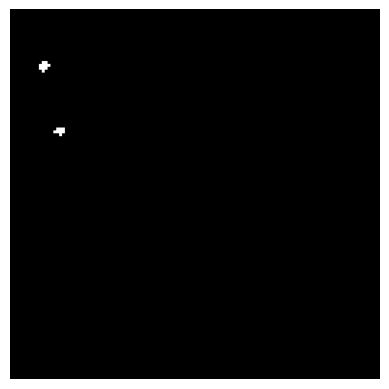

In [168]:
plt.imshow(mic_pred[R:R+P,C:C+P] > 0, cmap='gray')
plt.axis('off')
plt.show()

In [20]:
np.unique(mic_pred)

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33,
       34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50,
       51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67,
       68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84,
       85, 86, 87, 88, 89, 90, 91, 92], dtype=uint16)

# Dilation by 2

In [169]:
mic_crop = mic_pred[R:R+P,C:C+P] > 0
dilation = skimage.morphology.disk(2)
dilated = skimage.morphology.dilation(mic_crop, dilation)

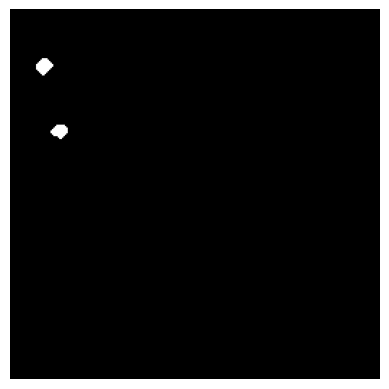

In [170]:
plt.imshow(dilated, cmap='gray')
plt.axis('off')
plt.show()